In [1]:
import os, pickle, time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from scipy.signal import stft
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from google.colab import drive
try:
    drive.mount("/content/drive")
except Exception:
    pass

MOBIFALL_DIR = "/content/drive/MyDrive/mobifall_processed"
OUT_DIR = "/content/drive/MyDrive/transfer_D"
os.makedirs(OUT_DIR, exist_ok=True)

print("GPU:", tf.config.list_physical_devices("GPU"))
print("MobiFall files:", sorted([f for f in os.listdir(MOBIFALL_DIR) if f.endswith(".npz")]))

def load_mobifall(ws, task):
    d = np.load(f"{MOBIFALL_DIR}/mobifall_w{ws}s.npz", allow_pickle=True)
    X = d["X"]
    y_subj = d["y_subject"]
    if task == "binary":
        y = d["y_binary"]
    elif task == "fall4":
        mask = d["fall_mask"]
        X, y, y_subj = X[mask], d["y_fall4"][mask], y_subj[mask]
    elif task == "multi13":
        y = d["y_multi13"]
    return X, y, y_subj

Mounted at /content/drive
GPU: []
MobiFall files: ['mobifall_w1s.npz', 'mobifall_w2s.npz', 'mobifall_w3s.npz']


In [2]:
def window_to_spectrogram_image(X_window, fs=100, nperseg=32, noverlap=24, img_size=224):
    """
    X_window: (T, 6) raw signal
    Returns: (img_size, img_size, 3) float32 image in [0, 255]

    Layout: top half = acc channels (RGB = x,y,z), bottom half = gyro channels (RGB = x,y,z)
    """
    spectra = []
    for ch in range(6):
        _, _, Z = stft(X_window[:, ch], fs=fs, nperseg=nperseg, noverlap=noverlap)
        mag = np.abs(Z)
        mag = np.log1p(mag)
        spectra.append(mag)

    acc_img = np.stack(spectra[:3], axis=-1)
    gyro_img = np.stack(spectra[3:], axis=-1)
    combined = np.concatenate([acc_img, gyro_img], axis=0)

    def norm_per_channel(img):
        out = np.zeros_like(img)
        for c in range(img.shape[-1]):
            v = img[..., c]
            lo, hi = v.min(), v.max()
            if hi > lo:
                out[..., c] = 255 * (v - lo) / (hi - lo)
        return out

    combined = norm_per_channel(combined).astype(np.float32)

    img = tf.image.resize(combined[None, ...], (img_size, img_size),
                          method=tf.image.ResizeMethod.BILINEAR).numpy()[0]
    return img

X, y, _ = load_mobifall(ws=3, task="binary")
sample_img = window_to_spectrogram_image(X[0])
print(f"Raw window shape: {X[0].shape}")
print(f"Spectrogram image shape: {sample_img.shape}")
print(f"Value range: [{sample_img.min():.1f}, {sample_img.max():.1f}]")

Raw window shape: (300, 6)
Spectrogram image shape: (224, 224, 3)
Value range: [0.0, 254.9]


In [4]:
def window_to_spectrogram_image(X_window, fs=100, nperseg=32, noverlap=24, img_size=224):
    """
    X_window: (T, 6) raw signal
    Returns: (img_size, img_size, 3) float32 image in [0, 255]

    Layout: top half = acc channels (RGB = x,y,z), bottom half = gyro channels (RGB = x,y,z)
    """
    spectra = []
    for ch in range(6):
        _, _, Z = stft(X_window[:, ch], fs=fs, nperseg=nperseg, noverlap=noverlap)
        mag = np.abs(Z)
        mag = np.log1p(mag)
        spectra.append(mag)

    acc_img = np.stack(spectra[:3], axis=-1)
    gyro_img = np.stack(spectra[3:], axis=-1)
    combined = np.concatenate([acc_img, gyro_img], axis=0)

    def norm_per_channel(img):
        out = np.zeros_like(img)
        for c in range(img.shape[-1]):
            v = img[..., c]
            lo, hi = v.min(), v.max()
            if hi > lo:
                out[..., c] = 255 * (v - lo) / (hi - lo)
        return out

    combined = norm_per_channel(combined).astype(np.float32)

    img = tf.image.resize(combined[None, ...], (img_size, img_size),
                          method=tf.image.ResizeMethod.BILINEAR).numpy()[0]
    return img

X, y, _ = load_mobifall(ws=3, task="binary")
sample_img = window_to_spectrogram_image(X[0])
print(f"Raw window shape: {X[0].shape}")
print(f"Spectrogram image shape: {sample_img.shape}")
print(f"Value range: [{sample_img.min():.1f}, {sample_img.max():.1f}]")

Raw window shape: (300, 6)
Spectrogram image shape: (224, 224, 3)
Value range: [0.0, 254.9]


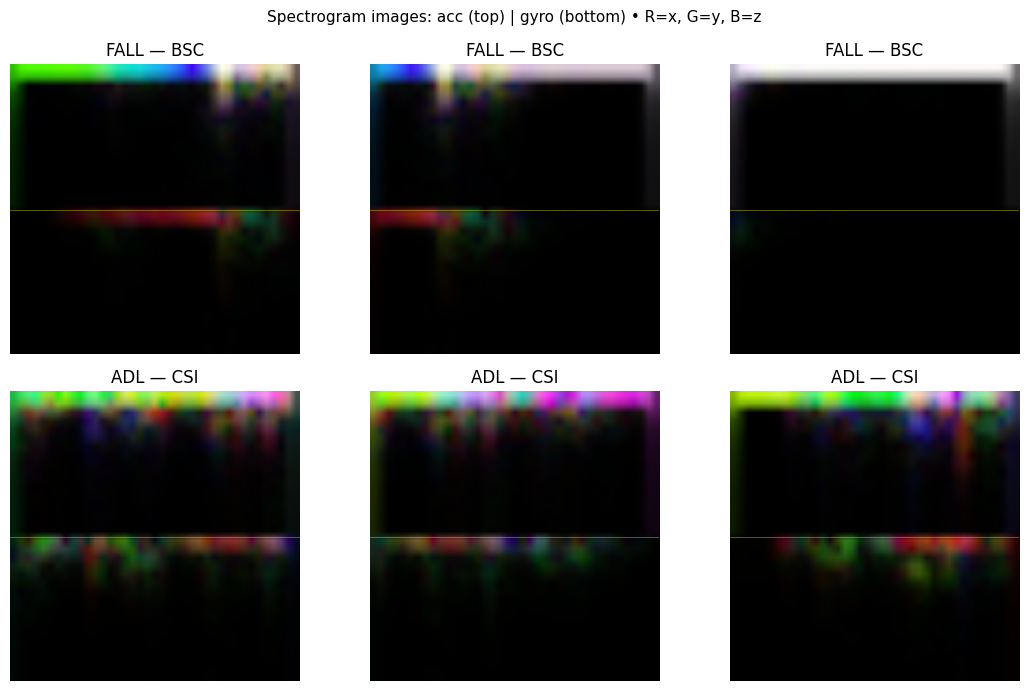

In [6]:
import matplotlib.pyplot as plt

X, y, _ = load_mobifall(ws=3, task="binary")
d = np.load(f"{MOBIFALL_DIR}/mobifall_w3s.npz", allow_pickle=True)
y_act = d["y_activity"]
fall_mask = d["fall_mask"]

fall_idx = np.where(fall_mask)[0][:3]
adl_idx = np.where(~fall_mask)[0][:3]

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for col, idx in enumerate(fall_idx):
    img = window_to_spectrogram_image(X[idx])
    axes[0, col].imshow(img.astype(np.uint8))
    axes[0, col].set_title(f"FALL — {y_act[idx]}")
    axes[0, col].axhline(112, color="yellow", lw=0.5, alpha=0.5)
    axes[0, col].axis("off")
for col, idx in enumerate(adl_idx):
    img = window_to_spectrogram_image(X[idx])
    axes[1, col].imshow(img.astype(np.uint8))
    axes[1, col].set_title(f"ADL — {y_act[idx]}")
    axes[1, col].axhline(112, color="yellow", lw=0.5, alpha=0.5)
    axes[1, col].axis("off")

plt.suptitle("Spectrogram images: acc (top) | gyro (bottom) • R=x, G=y, B=z",
             fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/spectrogram_samples.png", dpi=1200, bbox_inches="tight")
plt.show()

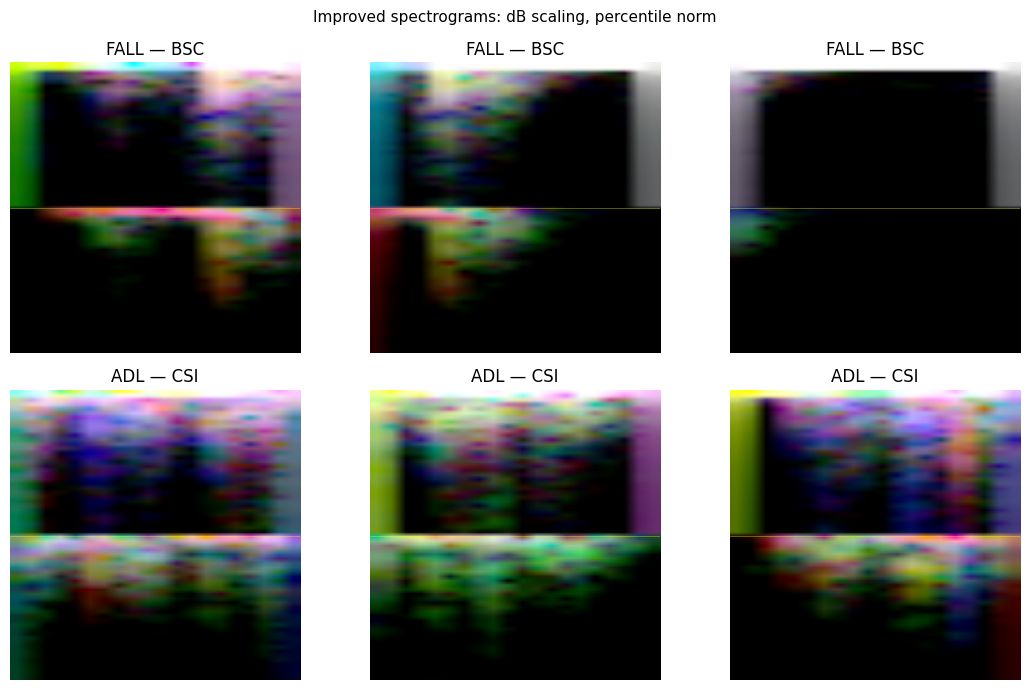

In [8]:
def window_to_spectrogram_image(X_window, fs=100, nperseg=64, noverlap=48,
                                 img_size=224, db_floor=-40):
    spectra = []
    for ch in range(6):
        _, _, Z = stft(X_window[:, ch], fs=fs, nperseg=nperseg, noverlap=noverlap)
        mag = np.abs(Z)
        mag_db = 20 * np.log10(mag + 1e-8)
        mag_db = np.clip(mag_db, db_floor, None)
        spectra.append(mag_db)

    acc_img = np.stack(spectra[:3], axis=-1)
    gyro_img = np.stack(spectra[3:], axis=-1)
    combined = np.concatenate([acc_img, gyro_img], axis=0)

    def norm_per_channel(img):
        out = np.zeros_like(img)
        for c in range(img.shape[-1]):
            v = img[..., c]
            lo = np.percentile(v, 2)
            hi = np.percentile(v, 98)
            if hi > lo:
                out[..., c] = 255 * np.clip((v - lo) / (hi - lo), 0, 1)
        return out

    combined = norm_per_channel(combined).astype(np.float32)
    img = tf.image.resize(combined[None, ...], (img_size, img_size),
                          method=tf.image.ResizeMethod.BILINEAR).numpy()[0]
    return img

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
fall_idx = np.where(fall_mask)[0][:3]
adl_idx = np.where(~fall_mask)[0][:3]
for col, idx in enumerate(fall_idx):
    img = window_to_spectrogram_image(X[idx])
    axes[0, col].imshow(img.astype(np.uint8))
    axes[0, col].set_title(f"FALL — {y_act[idx]}")
    axes[0, col].axhline(112, color="yellow", lw=0.5, alpha=0.5)
    axes[0, col].axis("off")
for col, idx in enumerate(adl_idx):
    img = window_to_spectrogram_image(X[idx])
    axes[1, col].imshow(img.astype(np.uint8))
    axes[1, col].set_title(f"ADL — {y_act[idx]}")
    axes[1, col].axhline(112, color="yellow", lw=0.5, alpha=0.5)
    axes[1, col].axis("off")
plt.suptitle("Improved spectrograms: dB scaling, percentile norm", fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/spectrogram_samples_v2.png", dpi=1200, bbox_inches="tight")
plt.show()

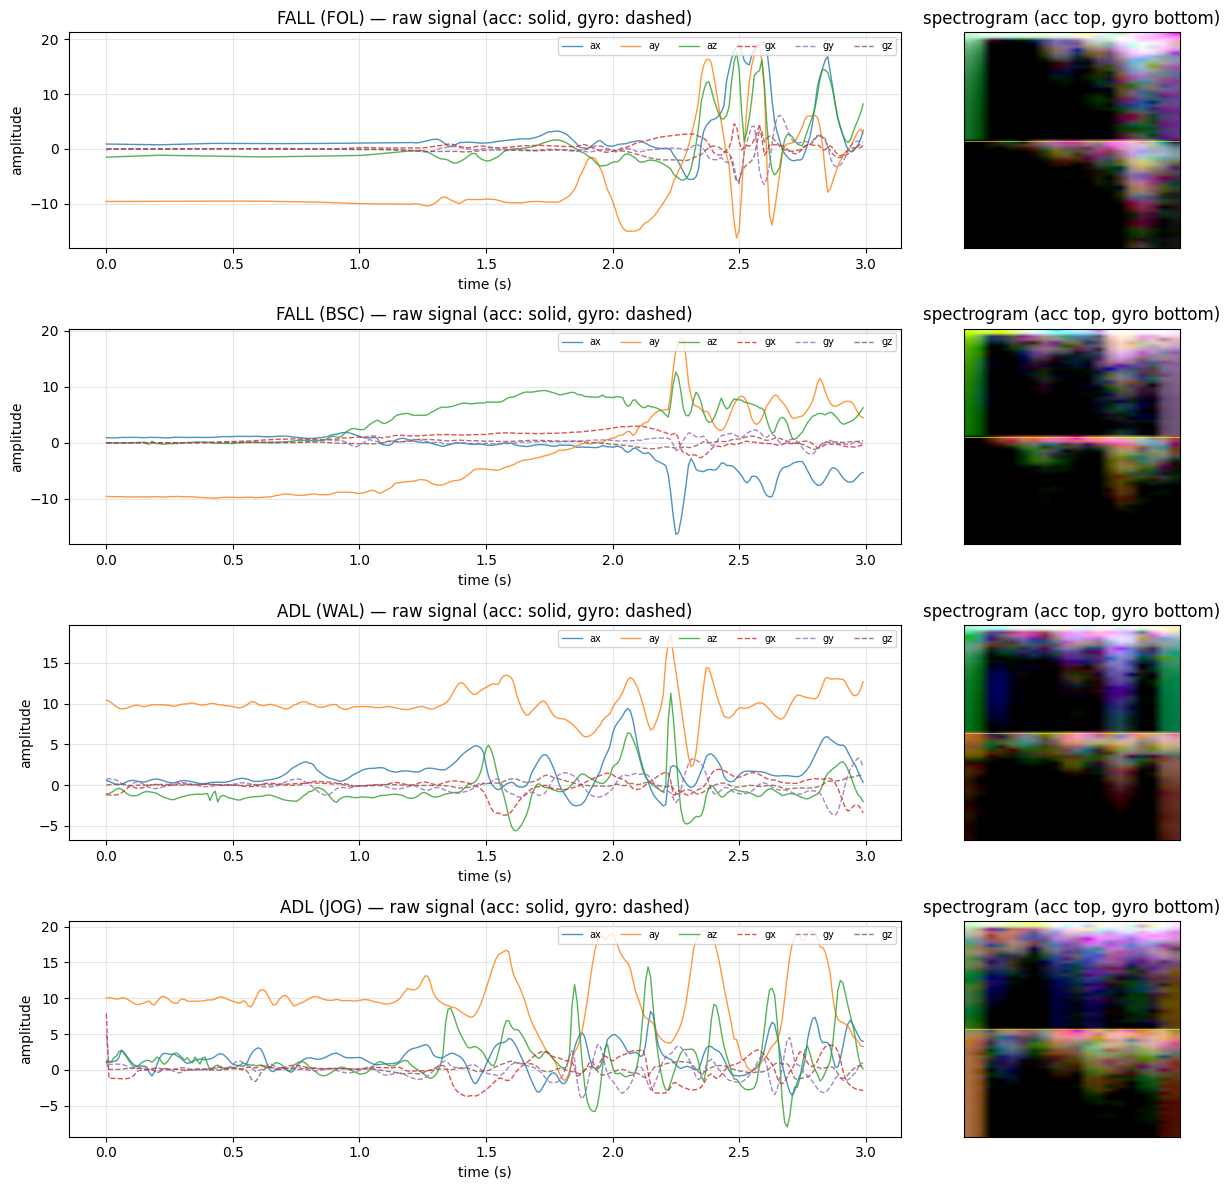

In [9]:
import matplotlib.pyplot as plt

X, y, _ = load_mobifall(ws=3, task="binary")
d = np.load(f"{MOBIFALL_DIR}/mobifall_w3s.npz", allow_pickle=True)
y_act = d["y_activity"]
fall_mask = d["fall_mask"]

selected = {
    "FALL (FOL)": np.where(y_act == "FOL")[0][0],
    "FALL (BSC)": np.where(y_act == "BSC")[0][0],
    "ADL (WAL)":  np.where(y_act == "WAL")[0][0],
    "ADL (JOG)":  np.where(y_act == "JOG")[0][0],
}

ch_names = ["ax","ay","az","gx","gy","gz"]
t_axis = np.arange(300) / 100.0

fig, axes = plt.subplots(len(selected), 2, figsize=(13, 3 * len(selected)),
                         gridspec_kw={"width_ratios": [2, 1]})

for row, (label, idx) in enumerate(selected.items()):
    sig = X[idx]
    ax_sig = axes[row, 0]
    for c in range(3):
        ax_sig.plot(t_axis, sig[:, c], label=ch_names[c], alpha=0.8, lw=1)
    for c in range(3, 6):
        ax_sig.plot(t_axis, sig[:, c], label=ch_names[c], alpha=0.8, lw=1,
                    linestyle="--")
    ax_sig.set_title(f"{label} — raw signal (acc: solid, gyro: dashed)")
    ax_sig.set_xlabel("time (s)")
    ax_sig.set_ylabel("amplitude")
    ax_sig.legend(ncol=6, fontsize=7, loc="upper right")
    ax_sig.grid(alpha=0.3)

    ax_spec = axes[row, 1]
    img = window_to_spectrogram_image(sig)
    ax_spec.imshow(img.astype(np.uint8))
    ax_spec.axhline(112, color="yellow", lw=0.6, alpha=0.7)
    ax_spec.set_title("spectrogram (acc top, gyro bottom)")
    ax_spec.set_xticks([]); ax_spec.set_yticks([])

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/signal_vs_spectrogram.png", dpi=140, bbox_inches="tight")
plt.show()

In [10]:
def batch_convert_to_spectrograms(X, desc=""):
    N = len(X)
    out = np.zeros((N, 224, 224, 3), dtype=np.uint8)
    for i in range(N):
        img = window_to_spectrogram_image(X[i])
        out[i] = np.clip(img, 0, 255).astype(np.uint8)
        if (i + 1) % 200 == 0:
            print(f"  {desc}: {i+1}/{N}")
    return out

for ws in [3]:
    for task in ["binary", "fall4", "multi13"]:
        X, y, subj = load_mobifall(ws, task)
        print(f"\n[ws={ws}s, task={task}] Converting {len(X)} windows...")
        t0 = time.time()
        X_img = batch_convert_to_spectrograms(X, desc=f"w{ws}_{task}")
        print(f"  Done in {time.time()-t0:.1f}s. Shape: {X_img.shape}")
        np.savez_compressed(
            f"/content/spec_w{ws}_{task}.npz",
            X_img=X_img, y=y, y_subject=subj
        )
        size_mb = os.path.getsize(f"/content/spec_w{ws}_{task}.npz") / 1e6
        print(f"  Saved: spec_w{ws}_{task}.npz ({size_mb:.1f} MB)")


[ws=3s, task=binary] Converting 3821 windows...
  w3_binary: 200/3821
  w3_binary: 400/3821
  w3_binary: 600/3821
  w3_binary: 800/3821
  w3_binary: 1000/3821
  w3_binary: 1200/3821
  w3_binary: 1400/3821
  w3_binary: 1600/3821
  w3_binary: 1800/3821
  w3_binary: 2000/3821
  w3_binary: 2200/3821
  w3_binary: 2400/3821
  w3_binary: 2600/3821
  w3_binary: 2800/3821
  w3_binary: 3000/3821
  w3_binary: 3200/3821
  w3_binary: 3400/3821
  w3_binary: 3600/3821
  w3_binary: 3800/3821
  Done in 19.5s. Shape: (3821, 224, 224, 3)
  Saved: spec_w3_binary.npz (275.8 MB)

[ws=3s, task=fall4] Converting 1444 windows...
  w3_fall4: 200/1444
  w3_fall4: 400/1444
  w3_fall4: 600/1444
  w3_fall4: 800/1444
  w3_fall4: 1000/1444
  w3_fall4: 1200/1444
  w3_fall4: 1400/1444
  Done in 7.3s. Shape: (1444, 224, 224, 3)
  Saved: spec_w3_fall4.npz (66.4 MB)

[ws=3s, task=multi13] Converting 3821 windows...
  w3_multi13: 200/3821
  w3_multi13: 400/3821
  w3_multi13: 600/3821
  w3_multi13: 800/3821
  w3_multi13: 1

In [12]:
def build_resnet_transfer_model(n_classes, wd=1e-4):
    base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    inp = Input(shape=(224, 224, 3), name="spec_input")
    x = preprocess_input(inp)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D(name="features")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=tf.keras.regularizers.l2(wd),
                     name="head_dense")(x)
    x = layers.Dropout(0.3)(x)
    if n_classes == 2:
        out = layers.Dense(1, activation="sigmoid", name="head_out")(x)
    else:
        out = layers.Dense(n_classes, activation="softmax", name="head_out")(x)
    return Model(inp, out, name=f"resnet_transfer_{n_classes}cls"), base

def load_spec(ws, task):
    d = np.load(f"/content/spec_w{ws}_{task}.npz", allow_pickle=True)
    return d["X_img"], d["y"], d["y_subject"]

def split_spec(X, y, seed=42):
    idx = np.arange(len(X))
    trv, te = train_test_split(idx, test_size=0.2, stratify=y, random_state=seed)
    tr, va = train_test_split(trv, test_size=0.2, stratify=y[trv], random_state=seed)
    return (X[tr], y[tr]), (X[va], y[va]), (X[te], y[te])

In [15]:
import tensorflow as tf

print("TF version:", tf.__version__)
print("GPUs visible:", tf.config.list_physical_devices("GPU"))
print("Logical GPUs:", tf.config.list_logical_devices("GPU"))

with tf.device("/GPU:0"):
    a = tf.random.normal([1000, 1000])
    b = tf.random.normal([1000, 1000])
    c = tf.matmul(a, b)
print("GPU test tensor:", c.device)

TF version: 2.19.0
GPUs visible: []
Logical GPUs: []
GPU test tensor: /job:localhost/replica:0/task:0/device:CPU:0


In [1]:
import shutil, os
os.makedirs("/content/drive/MyDrive/transfer_D", exist_ok=True)
for task in ["binary", "fall4", "multi13"]:
    src = f"/content/spec_w3_{task}.npz"
    if os.path.exists(src):
        shutil.copy(src, f"/content/drive/MyDrive/transfer_D/spec_w3_{task}.npz")
        print(f"Saved {task}: {os.path.getsize(src)/1e6:.1f} MB")
    else:
        print(f"MISSING: {src}")

MISSING: /content/spec_w3_binary.npz
MISSING: /content/spec_w3_fall4.npz
MISSING: /content/spec_w3_multi13.npz


In [1]:
import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices("GPU"))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
print(os.listdir("/content/drive/MyDrive/mobifall_processed"))

Mounted at /content/drive
['mobifall_w2s.npz', 'mobifall_w1s.npz', 'mobifall_w3s.npz', 'fig_fall4_cm.png', 'fig_binary_loss.png', 'fig_fall4_multi13_loss.png', 'fig_binary_cm.png', 'task3_multi13_results.pkl', 'fig_multi13_cm.png', 'task3_binary_results.pkl', 'task3_fall4_results.pkl']


In [3]:
import os, pickle, time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from scipy.signal import stft
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

MOBIFALL_DIR = "/content/drive/MyDrive/mobifall_processed"
OUT_DIR = "/content/drive/MyDrive/transfer_D"
os.makedirs(OUT_DIR, exist_ok=True)

def load_mobifall(ws, task):
    d = np.load(f"{MOBIFALL_DIR}/mobifall_w{ws}s.npz", allow_pickle=True)
    X = d["X"]; y_subj = d["y_subject"]
    if task == "binary":
        y = d["y_binary"]
    elif task == "fall4":
        mask = d["fall_mask"]
        X, y, y_subj = X[mask], d["y_fall4"][mask], y_subj[mask]
    elif task == "multi13":
        y = d["y_multi13"]
    return X, y, y_subj

def window_to_spec(X_window, fs=100, nperseg=64, noverlap=48, img_size=224, db_floor=-40):
    spectra = []
    for ch in range(6):
        _, _, Z = stft(X_window[:, ch], fs=fs, nperseg=nperseg, noverlap=noverlap)
        mag = 20 * np.log10(np.abs(Z) + 1e-8)
        spectra.append(np.clip(mag, db_floor, None))
    acc_img = np.stack(spectra[:3], axis=-1)
    gyro_img = np.stack(spectra[3:], axis=-1)
    combined = np.concatenate([acc_img, gyro_img], axis=0)
    out = np.zeros_like(combined)
    for c in range(3):
        v = combined[..., c]
        lo, hi = np.percentile(v, 2), np.percentile(v, 98)
        if hi > lo:
            out[..., c] = 255 * np.clip((v - lo) / (hi - lo), 0, 1)
    img = tf.image.resize(out[None, ...].astype(np.float32),
                          (img_size, img_size)).numpy()[0]
    return img

def batch_convert(X):
    out = np.zeros((len(X), 224, 224, 3), dtype=np.uint8)
    for i in range(len(X)):
        out[i] = np.clip(window_to_spec(X[i]), 0, 255).astype(np.uint8)
    return out

for task in ["binary", "fall4", "multi13"]:
    path = f"/content/spec_w3_{task}.npz"
    if os.path.exists(path):
        print(f"  cached: {task}")
        continue
    X, y, subj = load_mobifall(ws=3, task=task)
    print(f"Converting {task}: {len(X)} windows...", end=" ", flush=True)
    t0 = time.time()
    X_img = batch_convert(X)
    print(f"{time.time()-t0:.1f}s")
    np.savez_compressed(path, X_img=X_img, y=y, y_subject=subj)
print("\nSpectrogram cache ready.")

Converting binary: 3821 windows... 14.1s
Converting fall4: 1444 windows... 5.3s
Converting multi13: 3821 windows... 13.9s

Spectrogram cache ready.


In [4]:
BACKBONES = {
    "resnet50": (ResNet50, resnet_preprocess, 30),
    "vgg16":    (VGG16,    vgg_preprocess,    8),
}

def build_img_transfer_model(backbone_name, n_classes, wd=1e-4):
    BackboneCls, preprocess_fn, _ = BACKBONES[backbone_name]
    base = BackboneCls(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    inp = Input(shape=(224, 224, 3), name="spec_input")
    x = layers.Lambda(lambda z: preprocess_fn(tf.cast(z, tf.float32)), name="preprocess")(inp)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D(name="features")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=tf.keras.regularizers.l2(wd),
                     name="head_dense")(x)
    x = layers.Dropout(0.3)(x)
    if n_classes == 2:
        out = layers.Dense(1, activation="sigmoid", name="head_out")(x)
    else:
        out = layers.Dense(n_classes, activation="softmax", name="head_out")(x)
    return Model(inp, out, name=f"{backbone_name}_{n_classes}cls"), base

def load_spec(task):
    d = np.load(f"/content/spec_w3_{task}.npz", allow_pickle=True)
    return d["X_img"], d["y"], d["y_subject"]

def split_spec(X, y, seed=42):
    idx = np.arange(len(X))
    trv, te = train_test_split(idx, test_size=0.2, stratify=y, random_state=seed)
    tr, va = train_test_split(trv, test_size=0.2, stratify=y[trv], random_state=seed)
    return (X[tr], y[tr]), (X[va], y[va]), (X[te], y[te])

def finetune_img(backbone_name, task, seed=42):
    n_classes = {"binary": 2, "fall4": 4, "multi13": 13}[task]
    _, _, unfreeze_top_n = BACKBONES[backbone_name]

    X, y, _ = load_spec(task)
    (X_tr, y_tr), (X_va, y_va), (X_te, y_te) = split_spec(X, y, seed=seed)

    model, base = build_img_transfer_model(backbone_name, n_classes)
    loss = "binary_crossentropy" if n_classes == 2 else "sparse_categorical_crossentropy"

    base.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=loss, metrics=["accuracy"])
    t0 = time.time()
    h1 = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                   epochs=12, batch_size=32, verbose=0,
                   callbacks=[tf.keras.callbacks.EarlyStopping(
                       patience=5, restore_best_weights=True, monitor="val_loss")])
    t1 = time.time() - t0

    base.trainable = True
    for layer in base.layers[:-unfreeze_top_n]:
        layer.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss=loss, metrics=["accuracy"])
    t0 = time.time()
    h2 = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                   epochs=25, batch_size=32, verbose=0,
                   callbacks=[tf.keras.callbacks.EarlyStopping(
                       patience=6, restore_best_weights=True, monitor="val_loss")])
    t2 = time.time() - t0

    probs = model.predict(X_te, verbose=0)
    y_pred = (probs.ravel() > 0.5).astype(int) if n_classes == 2 else probs.argmax(1)
    return {
        "backbone": backbone_name, "task": task, "window_s": 3,
        "acc": float(accuracy_score(y_te, y_pred)),
        "f1_macro": float(f1_score(y_te, y_pred, average="macro")),
        "cm": confusion_matrix(y_te, y_pred),
        "stage1_epochs": len(h1.history["loss"]),
        "stage2_epochs": len(h2.history["loss"]),
        "time_s": float(t1 + t2),
        "history": {"stage1": h1.history, "stage2": h2.history},
    }

print("→ Validating: ResNet50 on binary")
r = finetune_img("resnet50", "binary")
print(f"acc={r['acc']:.4f}  f1={r['f1_macro']:.4f}  "
      f"epochs={r['stage1_epochs']}+{r['stage2_epochs']}  time={r['time_s']:.1f}s")
print(f"Baselines: Task3 CNN {0.9935}, Path B {0.9908}")

→ Validating: ResNet50 on binary
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
acc=0.9791  f1=0.9778  epochs=12+23  time=211.8s
Baselines: Task3 CNN 0.9935, Path B 0.9908


In [5]:
transfer_D_results = [r]

tasks = ["binary", "fall4", "multi13"]
for backbone in ["resnet50", "vgg16"]:
    for task in tasks:
        if backbone == "resnet50" and task == "binary":
            continue
        print(f"→ {backbone} • {task} ...", end=" ", flush=True)
        r = finetune_img(backbone, task)
        transfer_D_results.append(r)
        print(f"acc={r['acc']:.4f}  f1={r['f1_macro']:.4f}  "
              f"epochs={r['stage1_epochs']}+{r['stage2_epochs']}  "
              f"time={r['time_s']:.1f}s")

with open("/content/transfer_D_results.pkl", "wb") as f:
    pickle.dump(transfer_D_results, f)
import shutil
shutil.copy("/content/transfer_D_results.pkl",
            f"{OUT_DIR}/transfer_D_results.pkl")

import pandas as pd
df = pd.DataFrame([{k: v for k, v in r.items() if k not in ["cm","history"]}
                   for r in transfer_D_results])
df = df[["backbone","task","acc","f1_macro","time_s"]]
print("\n=== Path D Results: Spectrogram + ImageNet Transfer ===")
print(df.to_string(index=False))

→ resnet50 • fall4 ... acc=0.6505  f1=0.6511  epochs=12+18  time=111.8s
→ resnet50 • multi13 ... acc=0.7804  f1=0.7548  epochs=12+16  time=177.2s
→ vgg16 • binary ... Downloading data from https://storage.googleapis.com/tensorflow/keras-applications/vgg16/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
acc=0.9895  f1=0.9889  epochs=12+23  time=319.5s
→ vgg16 • fall4 ... acc=0.7059  f1=0.7049  epochs=7+25  time=136.2s
→ vgg16 • multi13 ... acc=0.8261  f1=0.8152  epochs=12+23  time=303.1s

=== Path D Results: Spectrogram + ImageNet Transfer ===
backbone    task      acc  f1_macro     time_s
resnet50  binary 0.979085  0.977845 211.807783
resnet50   fall4 0.650519  0.651072 111.750372
resnet50 multi13 0.780392  0.754828 177.190418
   vgg16  binary 0.989542  0.988893 319.523724
   vgg16   fall4 0.705882  0.704934 136.177907
   vgg16 multi13 0.826144  0.815167 303.101385


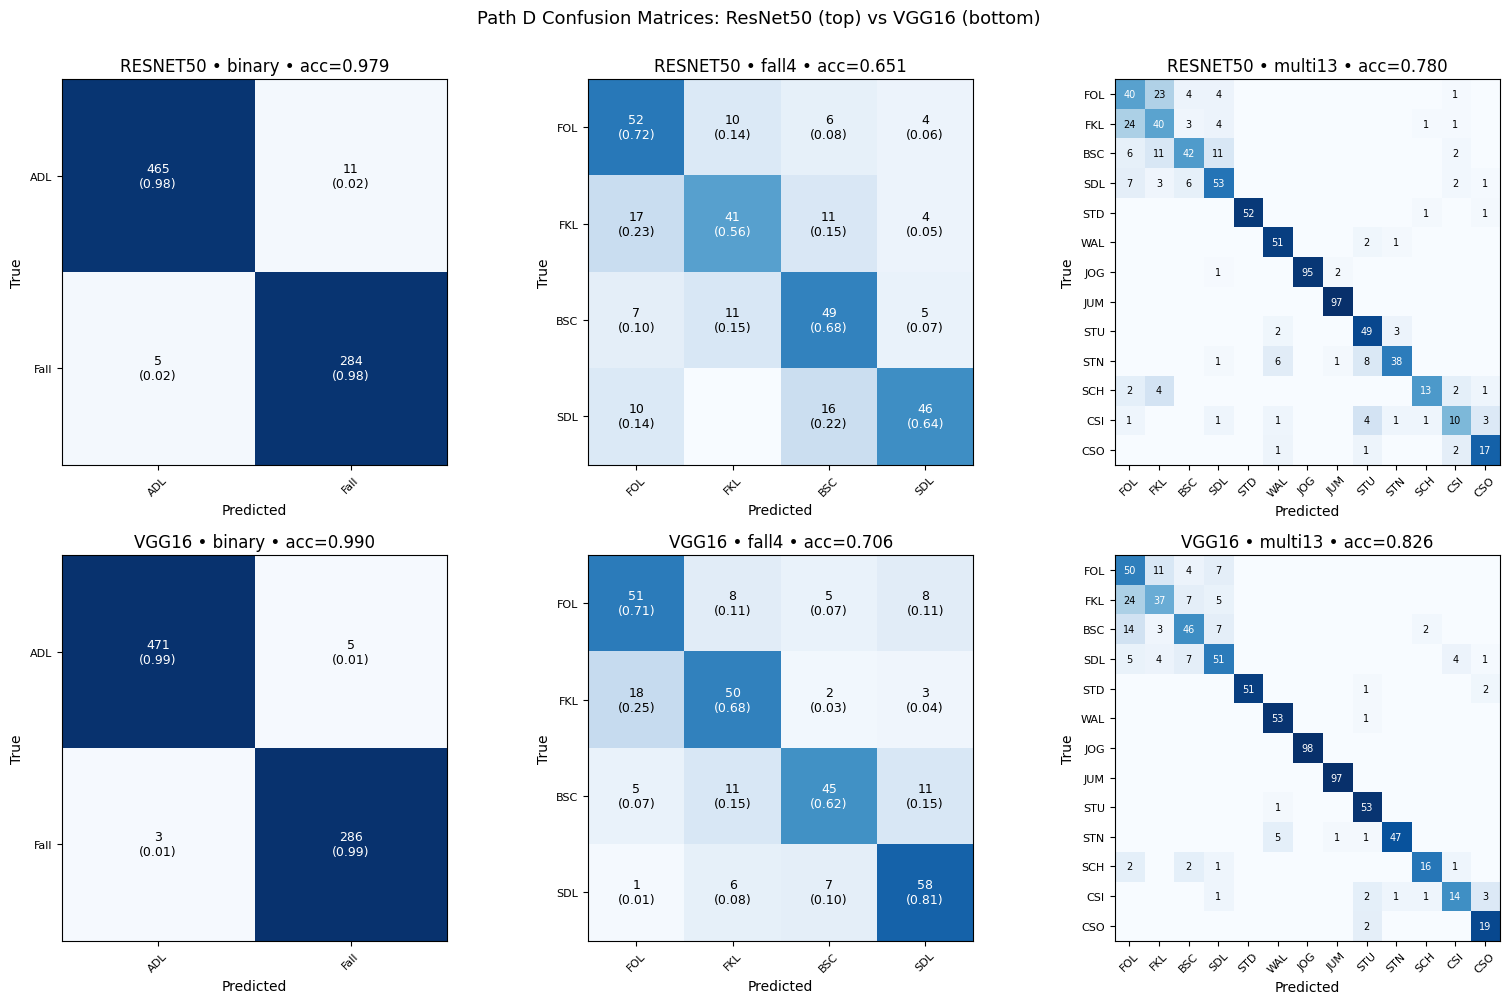

In [7]:
import matplotlib.pyplot as plt
import pickle

with open("/content/transfer_D_results.pkl", "rb") as f:
    transfer_D_results = pickle.load(f)

ALL_LABELS = {
    "binary":  ["ADL","Fall"],
    "fall4":   ["FOL","FKL","BSC","SDL"],
    "multi13": ["FOL","FKL","BSC","SDL","STD","WAL","JOG","JUM","STU","STN","SCH","CSI","CSO"],
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
tasks = ["binary", "fall4", "multi13"]
backbones = ["resnet50", "vgg16"]

for row, backbone in enumerate(backbones):
    for col, task in enumerate(tasks):
        r = next(r for r in transfer_D_results
                 if r["backbone"] == backbone and r["task"] == task)
        cm = r["cm"]
        labels = ALL_LABELS[task]
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        ax = axes[row, col]
        ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
        n = len(labels)
        for i in range(n):
            for j in range(n):
                if cm[i, j] > 0:
                    txt = f"{cm[i,j]}"
                    if n <= 4:
                        txt += f"\n({cm_norm[i,j]:.2f})"
                    ax.text(j, i, txt, ha="center", va="center",
                            color="white" if cm_norm[i,j] > 0.5 else "black",
                            fontsize=7 if n > 8 else 9)
        ax.set_xticks(range(n)); ax.set_xticklabels(labels, rotation=45, fontsize=8)
        ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(f"{backbone.upper()} • {task} • acc={r['acc']:.3f}")

plt.suptitle("Path D Confusion Matrices: ResNet50 (top) vs VGG16 (bottom)",
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_pathD_cm.png", dpi=1200, bbox_inches="tight")
plt.show()

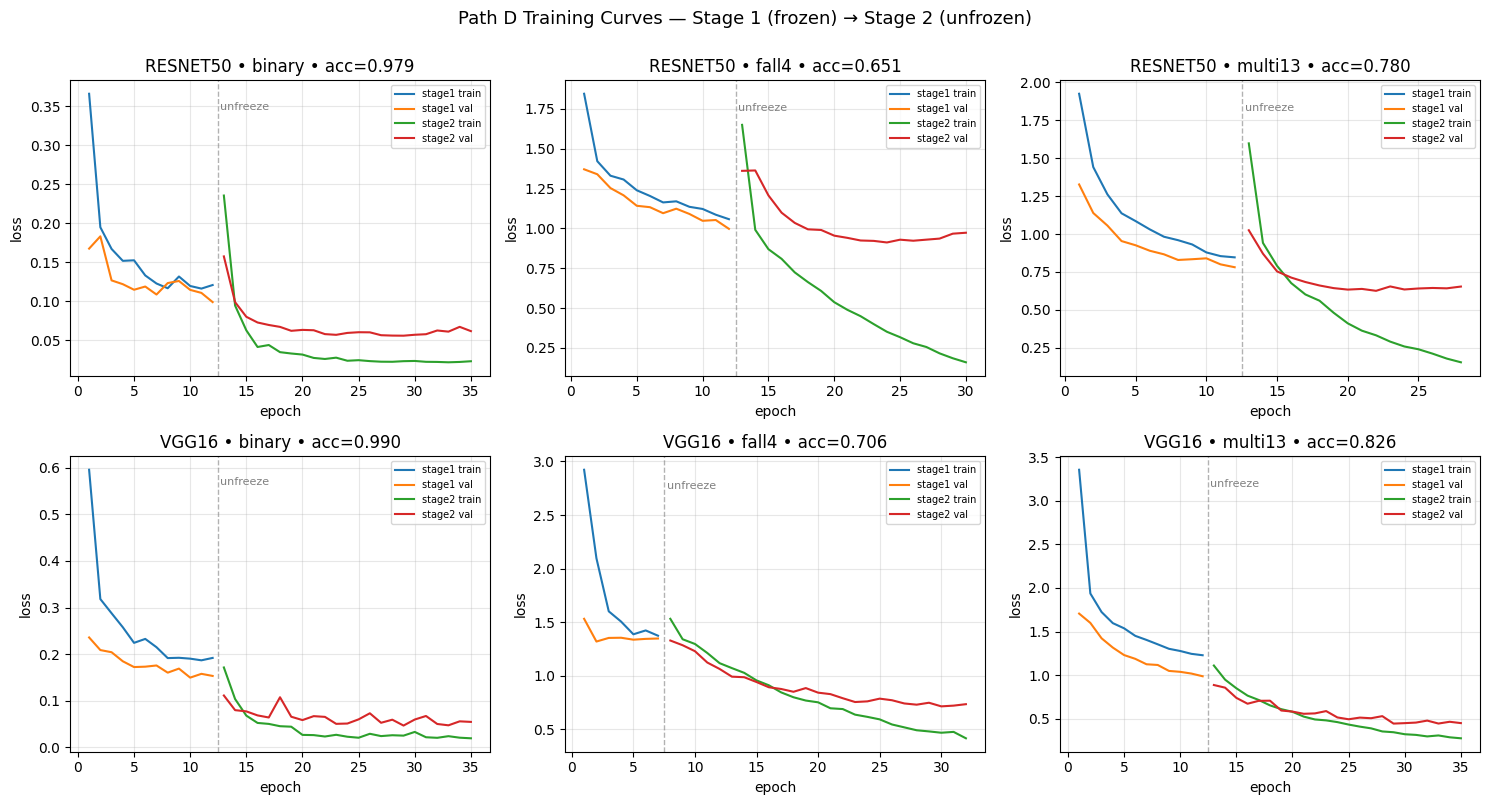

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, backbone in enumerate(["resnet50", "vgg16"]):
    for col, task in enumerate(["binary", "fall4", "multi13"]):
        r = next(r for r in transfer_D_results
                 if r["backbone"] == backbone and r["task"] == task)
        h1 = r["history"]["stage1"]
        h2 = r["history"]["stage2"]
        n1 = len(h1["loss"])

        ax = axes[row, col]
        ep1 = range(1, n1 + 1)
        ax.plot(ep1, h1["loss"], color="C0", label="stage1 train")
        ax.plot(ep1, h1["val_loss"], color="C1", label="stage1 val")

        ep2 = range(n1 + 1, n1 + 1 + len(h2["loss"]))
        ax.plot(ep2, h2["loss"], color="C2", label="stage2 train")
        ax.plot(ep2, h2["val_loss"], color="C3", label="stage2 val")

        ax.axvline(n1 + 0.5, color="gray", ls="--", lw=1, alpha=0.6)
        ax.text(n1 + 0.7, ax.get_ylim()[1] * 0.9, "unfreeze",
                fontsize=8, color="gray")

        ax.set_title(f"{backbone.upper()} • {task} • acc={r['acc']:.3f}")
        ax.set_xlabel("epoch"); ax.set_ylabel("loss")
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(alpha=0.3)

plt.suptitle("Path D Training Curves — Stage 1 (frozen) → Stage 2 (unfrozen)",
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_pathD_loss.png", dpi=1200, bbox_inches="tight")
plt.show()

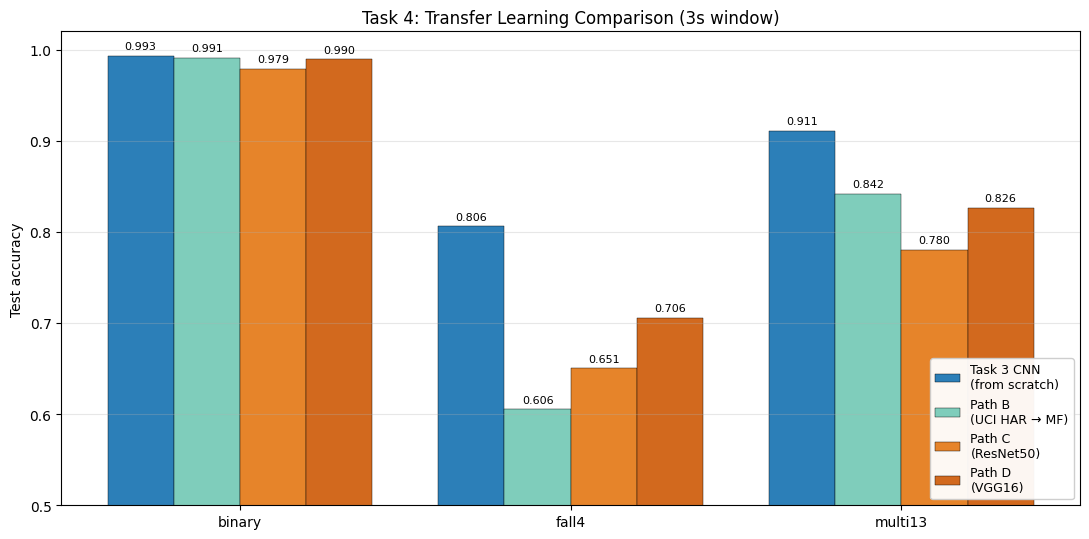

In [10]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

task3_results = {}
for task in ["binary", "fall4", "multi13"]:
    with open(f"/content/drive/MyDrive/mobifall_processed/task3_{task}_results.pkl", "rb") as f:
        rs = pickle.load(f)
    best = max([r for r in rs if r.get("window_s", 3) == 3 and r["model"] == "CNN"],
               key=lambda r: r["acc"])
    task3_results[task] = best["acc"]

pathB = {"binary": 0.9908, "fall4": 0.6055, "multi13": 0.8418}
pathD = {b: {} for b in ["resnet50", "vgg16"]}
for r in transfer_D_results:
    pathD[r["backbone"]][r["task"]] = r["acc"]

tasks = ["binary", "fall4", "multi13"]
methods = ["Task 3 CNN\n(from scratch)", "Path B\n(UCI HAR → MF)",
           "Path C\n(ResNet50)", "Path D\n(VGG16)"]
data = np.array([
    [task3_results[t] for t in tasks],
    [pathB[t] for t in tasks],
    [pathD["resnet50"][t] for t in tasks],
    [pathD["vgg16"][t] for t in tasks],
])

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(tasks)); w = 0.2
colors = ["#2c7fb8", "#7fcdbb", "#e6842a", "#d2691e"]
for i, (m, c) in enumerate(zip(methods, colors)):
    bars = ax.bar(x + (i - 1.5) * w, data[i], w, label=m, color=c, edgecolor="black", lw=0.3)
    for bar, v in zip(bars, data[i]):
        ax.text(bar.get_x() + w/2, v + 0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(tasks)
ax.set_ylabel("Test accuracy"); ax.set_ylim(0.5, 1.02)
ax.set_title("Task 4: Transfer Learning Comparison (3s window)")
ax.legend(loc="lower right", fontsize=9, framealpha=0.95)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig_task4_comparison.png", dpi=1200, bbox_inches="tight")
plt.show()